# 01. Computational Data Pipeline & Molecular Curation

**Study:** Machine Learning-Based Skin Sensitization Prediction and Cross-Endpoint Toxicity Screening  
**Objective:** Ingest benchmark *in vivo* toxicity datasets from the National Toxicology Program Integrated Chemical Environment (NTP ICE), perform chemical structure standardization using RDKit, resolve structure-label discordances, compute 2D physicochemical descriptors and structural fingerprints, explore chemical space, and export processed datasets for modeling.

---

### Computational Workflow Overview

```mermaid
flowchart TD
    A[NTP ICE In Vivo Benchmark Datasets<br/>Skin Sensitization / Skin Irritation / Eye Irritation] --> B[Endpoint Feature & Label Extraction]
    B --> C[Binary Response Harmonization]
    C --> D[SMILES Curation & RDKit Standardization]
    D --> E[Fragment Parent Isolation & Canonicalization]
    E --> F[Structure-Label Discordance Resolution]
    F --> G[Molecular Feature Generation<br/>- 10 2D Physicochemical Descriptors<br/>- Morgan Circular Fingerprints (1024-bit)<br/>- MACCS Structural Keys (166-bit)]
    G --> H[Chemical Space Exploration<br/>PCA / t-SNE / UMAP]
    H --> I[Processed Benchmark Datasets Export]
```


## 1. Environment Setup & Library Imports


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys, Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 100)

# Resolve the repository root whether Jupyter starts here or in notebooks/.
SEARCH_START = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (SEARCH_START, *SEARCH_START.parents)
     if (p / "README.md").is_file() and (p / "notebooks" / "01_data_pipeline.ipynb").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the Skin Sensitization project root.")
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"
RESULTS_TAB_DIR = PROJECT_ROOT / "results" / "tables"
for directory in (DATA_PROCESSED_DIR, RESULTS_FIG_DIR, RESULTS_TAB_DIR):
    directory.mkdir(parents=True, exist_ok=True)


## 2. In Vivo Benchmark Dataset Ingestion

We ingest three benchmark toxicity datasets from NTP ICE:
1. **Skin Sensitization** (LLNA / GPMT in vivo assays, ICE v4.2)
2. **Skin Irritation** (Draize in vivo rabbit assay, ICE v4.1)
3. **Eye Irritation** (Draize in vivo rabbit assay, ICE v4.2)

*Note on Data Privacy:* Dataset files are not redistributed in the public repository. If running locally, place `skin_sensitization.xlsx`, `skin_irritation.xlsx`, and `eye_irritation.xlsx` in `data/raw/` as described in `data/README.md`.


,Dataset,Assay Context,Raw Records
0,Skin Sensitization,In Vivo (LLNA / GPMT),13945
1,Skin Irritation,In Vivo Draize Skin,2058
2,Eye Irritation,In Vivo Draize Eye,3028


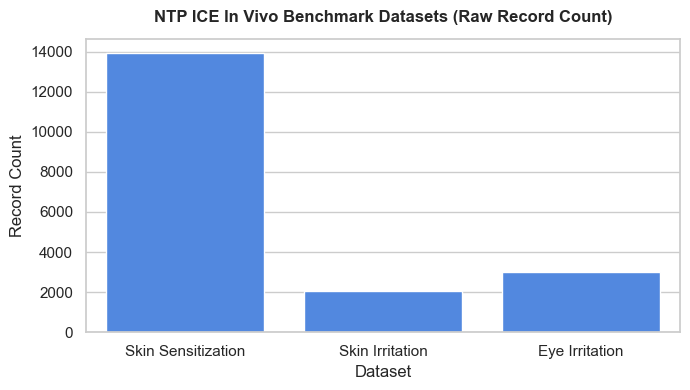

In [2]:
# Verify presence of raw dataset files
raw_sens_path = DATA_RAW_DIR / "skin_sensitization.xlsx"
raw_irrit_path = DATA_RAW_DIR / "skin_irritation.xlsx"
raw_eye_path = DATA_RAW_DIR / "eye_irritation.xlsx"

for p in [raw_sens_path, raw_irrit_path, raw_eye_path]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required raw dataset '{p.name}' not found in '{p.parent}'. "
            "Please obtain the file from the NTP ICE repository (https://ice.ntp.niehs.nih.gov/) "
            "and place it in data/raw/ before running this notebook. See data/README.md for instructions."
        )

# Load raw benchmark spreadsheets
sensitization_raw = pd.read_excel(raw_sens_path, sheet_name="Data_invivo")
irritation_raw = pd.read_excel(raw_irrit_path, sheet_name="Data_invivo")
eye_raw = pd.read_excel(raw_eye_path, sheet_name="Data")

raw_cohort_sizes = pd.DataFrame({
    "Dataset": ["Skin Sensitization", "Skin Irritation", "Eye Irritation"],
    "Assay Context": ["In Vivo (LLNA / GPMT)", "In Vivo Draize Skin", "In Vivo Draize Eye"],
    "Raw Records": [len(sensitization_raw), len(irritation_raw), len(eye_raw)]
})

display(raw_cohort_sizes)

# Plot raw record counts
plt.figure(figsize=(7, 4))
sns.barplot(data=raw_cohort_sizes, x="Dataset", y="Raw Records", color="#3b82f6")
plt.title("NTP ICE In Vivo Benchmark Datasets (Raw Record Count)", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "01_raw_dataset_sizes.png", dpi=300)
plt.show()


## 3. Structural Column Extraction & Binary Target Harmonization

We extract essential chemical identifiers (`Chemical_Name`, `CASRN`, `DTXSID`, `SMILES`) and toxicological responses (`Endpoint`, `Response`).
Responses are mapped to standardized binary labels ($1 = \text{toxic/active/irritant/sensitizer}$, $0 = \text{non-toxic/inactive/non-irritant/non-sensitizer}$):
- **Skin Sensitization:** `Active` / `Sensitizer` $\rightarrow 1$, `Inactive` / `Non-sensitizer` $\rightarrow 0$
- **Skin Irritation:** GHS Categories `1`, `2`, `3` $\rightarrow 1$, Category `4` $\rightarrow 0$
- **Eye Irritation:** GHS Categories `1`, `2`, `3`, `2A`, `2B` $\rightarrow 1$, Category `4` / `NC` $\rightarrow 0$


For the auxiliary eye-irritation cohort, only `EPA Classification` and `GHS Classification` rows are retained. Numerical Draize scores and other measured endpoints are not treated as classification labels.

In [3]:
core_columns = ["Chemical_Name", "CASRN", "DTXSID", "SMILES", "Endpoint", "Response"]

sensitization = sensitization_raw[core_columns].copy()
irritation = irritation_raw[core_columns].copy()
eye = eye_raw[core_columns].copy()

# Standardize response strings
sensitization["Response"] = sensitization["Response"].astype(str).str.strip()
irritation["Response"] = irritation["Response"].astype(str).str.strip().str.upper()
eye["Response"] = eye["Response"].astype(str).str.strip().str.upper()
# Keep classification endpoints only; measured score endpoints are not class labels.
eye = eye[eye["Endpoint"].isin(["EPA Classification", "GHS Classification"])].copy()

# Filter and binarize responses
sensitization = sensitization[sensitization["Response"].isin(["Active", "Inactive", "Sensitizer", "Non-sensitizer"])].copy()
sensitization["label"] = sensitization["Response"].map({"Active": 1, "Sensitizer": 1, "Inactive": 0, "Non-sensitizer": 0})

irritation = irritation[irritation["Response"].isin(["1", "2", "3", "4"])].copy()
irritation["label"] = irritation["Response"].map({"1": 1, "2": 1, "3": 1, "4": 0})

eye = eye[eye["Response"].isin(["1", "2", "3", "2A", "2B", "4", "NC"])].copy()
eye["label"] = eye["Response"].map({"1": 1, "2": 1, "3": 1, "2A": 1, "2B": 1, "4": 0, "NC": 0})

print("Harmonized record counts:")
print(f"  Skin Sensitization : {len(sensitization)} records (Positive: {sensitization['label'].sum()}, Negative: {(sensitization['label']==0).sum()})")
print(f"  Skin Irritation    : {len(irritation)} records (Positive: {irritation['label'].sum()}, Negative: {(irritation['label']==0).sum()})")
print(f"  Eye Irritation     : {len(eye)} records (Positive: {eye['label'].sum()}, Negative: {(eye['label']==0).sum()})")


Harmonized record counts:
  Skin Sensitization : 3256 records (Positive: 857, Negative: 2399)
  Skin Irritation    : 1799 records (Positive: 365, Negative: 1434)
  Eye Irritation     : 1349 records (Positive: 971, Negative: 378)


## 4. Molecular Structure Curation & RDKit Standardization

To ensure structural consistency for QSAR modeling:
1. Remove missing or empty SMILES strings.
2. Apply RDKit `rdMolStandardize.Cleanup` for charge normalization and functional group standardization.
3. Apply `rdMolStandardize.FragmentParent` to isolate the primary parent organic molecule and strip counterions/solvents.
4. Generate canonical SMILES strings.
5. Filter out invalid or unparseable structures.


In [4]:
def standardize_smiles(smiles):
    """Standardize SMILES by sanitization, fragment parent isolation, and canonicalization."""
    if pd.isna(smiles) or not isinstance(smiles, str) or not smiles.strip():
        return np.nan
    try:
        mol = Chem.MolFromSmiles(smiles.strip())
        if mol is None:
            return np.nan
        cleaner = rdMolStandardize.Cleanup(mol)
        parent = rdMolStandardize.FragmentParent(cleaner)
        return Chem.MolToSmiles(parent, canonical=True)
    except Exception:
        return np.nan

# Drop null initial SMILES
sensitization_clean = sensitization.dropna(subset=["SMILES"]).copy()
irritation_clean = irritation.dropna(subset=["SMILES"]).copy()
eye_clean = eye.dropna(subset=["SMILES"]).copy()

# Generate standardized SMILES
sensitization_clean["standardized_smi"] = sensitization_clean["SMILES"].map(standardize_smiles)
irritation_clean["standardized_smi"] = irritation_clean["SMILES"].map(standardize_smiles)
eye_clean["standardized_smi"] = eye_clean["SMILES"].map(standardize_smiles)

# Filter invalid structures
sensitization_clean = sensitization_clean.dropna(subset=["standardized_smi"]).copy()
irritation_clean = irritation_clean.dropna(subset=["standardized_smi"]).copy()
eye_clean = eye_clean.dropna(subset=["standardized_smi"]).copy()

print("Valid standardized molecular records:")
print(f"  Skin Sensitization : {len(sensitization_clean)}")
print(f"  Skin Irritation    : {len(irritation_clean)}")
print(f"  Eye Irritation     : {len(eye_clean)}")


Valid standardized molecular records:
  Skin Sensitization : 2849
  Skin Irritation    : 1708
  Eye Irritation     : 1281


## 5. Duplicate & Structure-Label Discordance Resolution

When compiling historical in vivo assay results across literature sources, identical chemical structures can occasionally have conflicting activity labels due to experimental protocol variations.
We apply a conflict filtering rule:
- Group records by `standardized_smi`.
- If an identical structure has conflicting binary labels (`label.nunique() > 1`), remove the discordant chemical from the modeling cohort.
- Retain a single unique representative row for concordant structures.


,Endpoint,Unique Compounds (N),Toxic / Active (1),Non-Toxic / Inactive (0),Active Prevalence (%)
0,Skin Sensitization,1185,146,1039,12.32
1,Skin Irritation,200,39,161,19.50
2,Eye Irritation,333,272,61,81.68


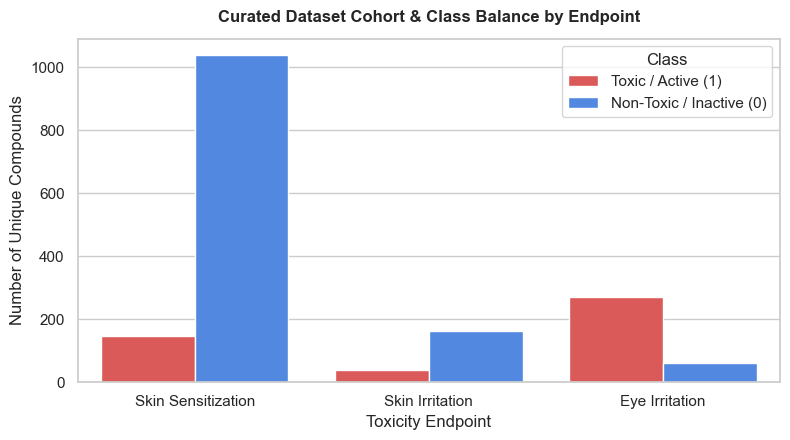

In [5]:
def resolve_structure_conflicts(df):
    """Filter out structures with conflicting class labels and remove exact structural duplicates."""
    label_counts = df.groupby("standardized_smi")["label"].nunique()
    valid_smiles = label_counts[label_counts == 1].index
    filtered_df = df[df["standardized_smi"].isin(valid_smiles)].copy()
    unique_df = filtered_df.drop_duplicates(subset=["standardized_smi"]).copy()
    return unique_df.reset_index(drop=True)

sensitization_final = resolve_structure_conflicts(sensitization_clean)
irritation_final = resolve_structure_conflicts(irritation_clean)
eye_final = resolve_structure_conflicts(eye_clean)

# Cohort curation summary table
curation_summary = pd.DataFrame([
    {
        "Endpoint": "Skin Sensitization",
        "Unique Compounds (N)": len(sensitization_final),
        "Toxic / Active (1)": int(sensitization_final["label"].sum()),
        "Non-Toxic / Inactive (0)": int((sensitization_final["label"] == 0).sum()),
        "Active Prevalence (%)": round(sensitization_final["label"].mean() * 100, 2)
    },
    {
        "Endpoint": "Skin Irritation",
        "Unique Compounds (N)": len(irritation_final),
        "Toxic / Active (1)": int(irritation_final["label"].sum()),
        "Non-Toxic / Inactive (0)": int((irritation_final["label"] == 0).sum()),
        "Active Prevalence (%)": round(irritation_final["label"].mean() * 100, 2)
    },
    {
        "Endpoint": "Eye Irritation",
        "Unique Compounds (N)": len(eye_final),
        "Toxic / Active (1)": int(eye_final["label"].sum()),
        "Non-Toxic / Inactive (0)": int((eye_final["label"] == 0).sum()),
        "Active Prevalence (%)": round(eye_final["label"].mean() * 100, 2)
    }
])

display(curation_summary)
curation_summary.to_csv(RESULTS_TAB_DIR / "cohort_summary.csv", index=False)

# Plot class distribution across endpoints
label_plot_data = pd.melt(
    curation_summary,
    id_vars=["Endpoint"],
    value_vars=["Toxic / Active (1)", "Non-Toxic / Inactive (0)"],
    var_name="Class",
    value_name="Count"
)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=label_plot_data, x="Endpoint", y="Count", hue="Class", palette=["#ef4444", "#3b82f6"])
plt.title("Curated Dataset Cohort & Class Balance by Endpoint", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Number of Unique Compounds")
plt.xlabel("Toxicity Endpoint")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "02_label_distribution.png", dpi=300)
plt.show()


## 6. Molecular Feature Generation: 2D Physicochemical Descriptors

We calculate 10 interpretable 2D RDKit molecular descriptors capturing:
- **Size & Mass:** Molecular Weight (`MolWt`), Heavy Atom Count (`HeavyAtomCount`)
- **Lipophilicity & Polarity:** Wildman-Crippen LogP (`MolLogP`), Topological Polar Surface Area (`TPSA`)
- **Hydrogen Bonding Capacity:** H-Bond Donors (`NumHDonors`), H-Bond Acceptors (`NumHAcceptors`)
- **Flexibility & Saturation:** Rotatable Bonds (`NumRotatableBonds`), Fraction of $sp^3$ Carbons (`FractionCSP3`)
- **Aromaticity & Rings:** Total Ring Count (`RingCount`), Aromatic Ring Count (`NumAromaticRings`)


In [6]:
descriptor_definitions = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "RingCount": Descriptors.RingCount,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "FractionCSP3": Descriptors.FractionCSP3,
}

def compute_descriptors(df):
    """Compute 10 2D RDKit physicochemical descriptors for each standardized SMILES."""
    desc_rows = []
    for smi in df["standardized_smi"]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            desc_rows.append([np.nan] * len(descriptor_definitions))
        else:
            desc_rows.append([func(mol) for func in descriptor_definitions.values()])
    desc_df = pd.DataFrame(desc_rows, columns=list(descriptor_definitions.keys()))
    return pd.concat([df.reset_index(drop=True), desc_df], axis=1)

sensitization_desc = compute_descriptors(sensitization_final)
irritation_desc = compute_descriptors(irritation_final)
eye_desc = compute_descriptors(eye_final)

print("Descriptor computation complete:")
print(f"  Skin Sensitization : {sensitization_desc.shape}")
print(f"  Skin Irritation    : {irritation_desc.shape}")
print(f"  Eye Irritation     : {eye_desc.shape}")


Descriptor computation complete:
  Skin Sensitization : (1185, 18)
  Skin Irritation    : (200, 18)
  Eye Irritation     : (333, 18)


## 7. Exploratory Analysis of Molecular Properties & Correlation


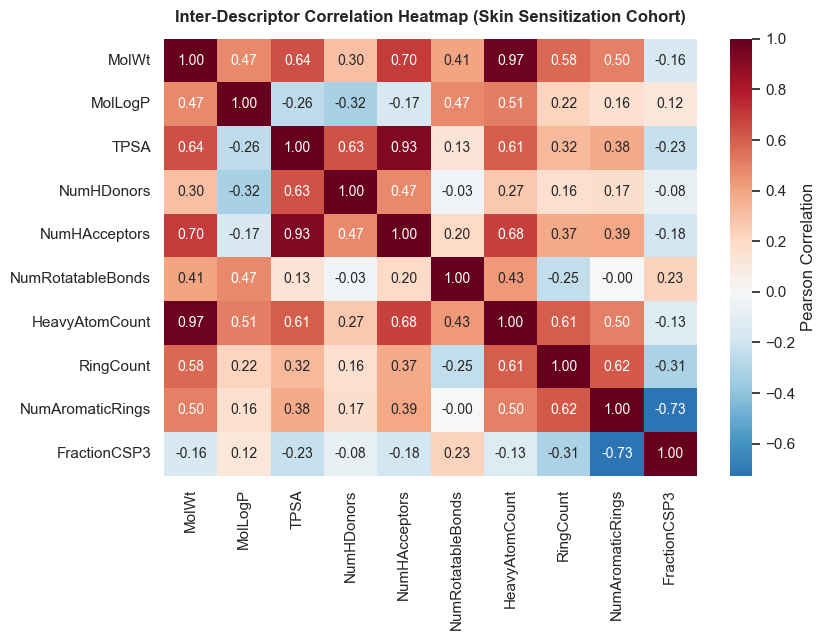

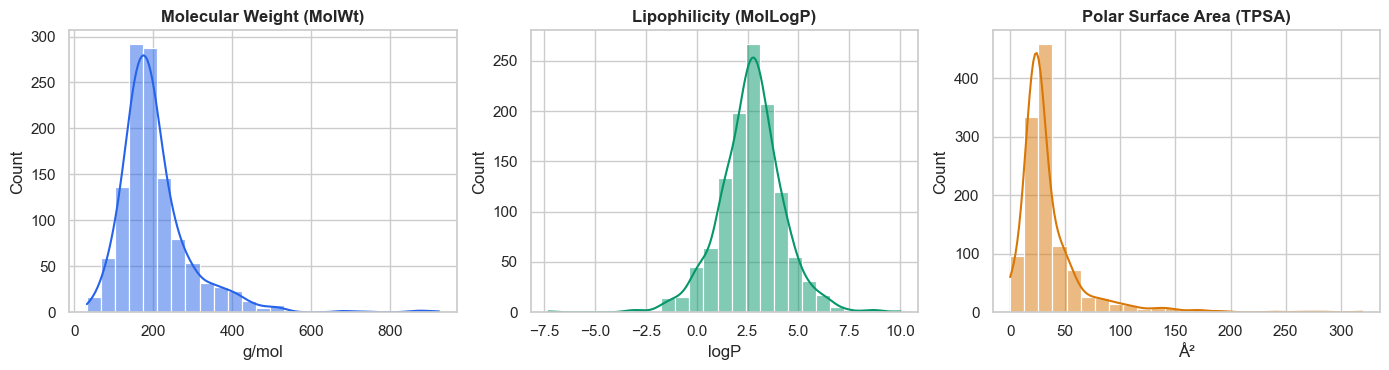

In [7]:
# Correlation matrix among physicochemical descriptors
numeric_descriptors = sensitization_desc[list(descriptor_definitions.keys())]
corr_matrix = numeric_descriptors.corr()

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=True, fmt=".2f", cbar_kws={"label": "Pearson Correlation"})
plt.title("Inter-Descriptor Correlation Heatmap (Skin Sensitization Cohort)", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "03_descriptor_correlation_heatmap.png", dpi=300)
plt.show()

# Physicochemical property distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
sns.histplot(sensitization_desc["MolWt"], bins=25, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Molecular Weight (MolWt)", fontweight="bold")
axes[0].set_xlabel("g/mol")

sns.histplot(sensitization_desc["MolLogP"], bins=25, kde=True, ax=axes[1], color="#059669")
axes[1].set_title("Lipophilicity (MolLogP)", fontweight="bold")
axes[1].set_xlabel("logP")

sns.histplot(sensitization_desc["TPSA"], bins=25, kde=True, ax=axes[2], color="#d97706")
axes[2].set_title("Polar Surface Area (TPSA)", fontweight="bold")
axes[2].set_xlabel("Å²")

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "04_property_distributions.png", dpi=300)
plt.show()


## 8. Structural Fingerprint Representation: Morgan & MACCS

For exploratory structural profiling and similarity analyses:
- **Morgan Circular Fingerprints:** Extended-connectivity circular fingerprints (radius = 2, 1024 bits).
- **MACCS Structural Keys:** 166 predefined structural key flags.


In [8]:
def compute_morgan_fingerprints(df, radius=2, n_bits=1024):
    """Compute Morgan circular bit vector fingerprints."""
    fp_rows = []
    for smi in df["standardized_smi"]:
        mol = Chem.MolFromSmiles(smi)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        fp_rows.append(list(fp))
    fp_df = pd.DataFrame(fp_rows)
    fp_df["label"] = df["label"].values
    return fp_df

def compute_maccs_keys(df):
    """Compute 166-bit MACCS structural keys."""
    maccs_rows = []
    for smi in df["standardized_smi"]:
        mol = Chem.MolFromSmiles(smi)
        fp = MACCSkeys.GenMACCSKeys(mol)
        maccs_rows.append(list(fp))
    maccs_df = pd.DataFrame(maccs_rows)
    maccs_df["label"] = df["label"].values
    return maccs_df

sensitization_fp = compute_morgan_fingerprints(sensitization_final)
irritation_fp = compute_morgan_fingerprints(irritation_final)
eye_fp = compute_morgan_fingerprints(eye_final)

sensitization_maccs = compute_maccs_keys(sensitization_final)
irritation_maccs = compute_maccs_keys(irritation_final)
eye_maccs = compute_maccs_keys(eye_final)

print("Fingerprint generation complete:")
print(f"  Morgan fingerprints shape : {sensitization_fp.shape}")
print(f"  MACCS keys shape          : {sensitization_maccs.shape}")


Fingerprint generation complete:
  Morgan fingerprints shape : (1185, 1025)
  MACCS keys shape          : (1185, 168)


## 9. Chemical Space Exploration: PCA, t-SNE, and UMAP

We assess the structural coverage and overlap between the primary training endpoint (**Skin Sensitization**) and the external screening endpoints (**Skin Irritation** and **Eye Irritation**) using linear (PCA) and non-linear (t-SNE, UMAP) projections of standardized physicochemical descriptors.


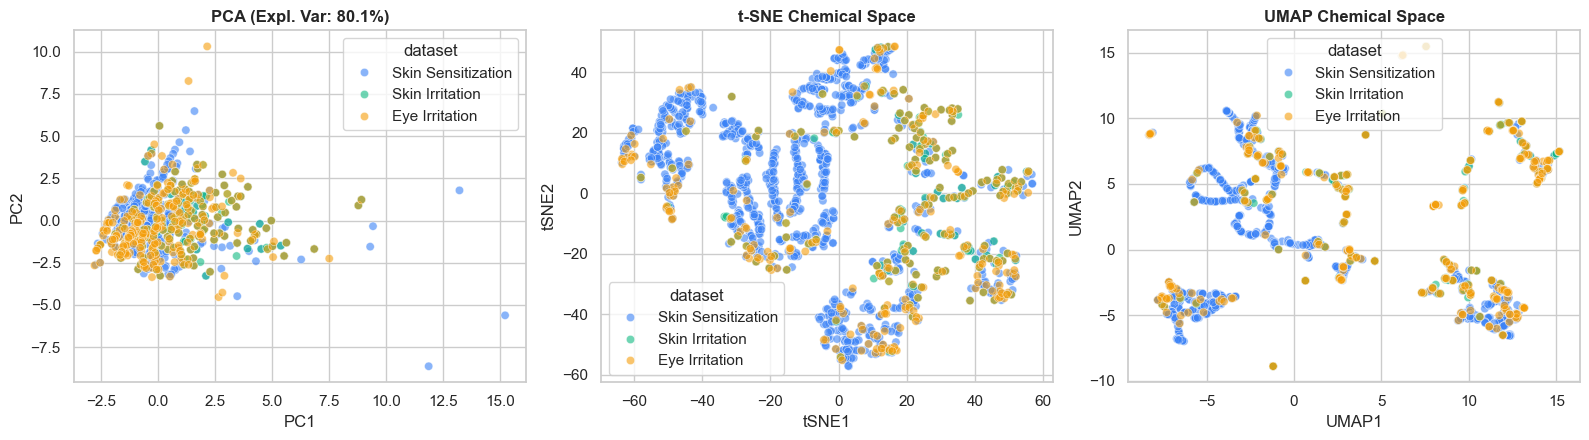

In [9]:
# Tag datasets
sensitization_desc["dataset"] = "Skin Sensitization"
irritation_desc["dataset"] = "Skin Irritation"
eye_desc["dataset"] = "Eye Irritation"

combined_desc = pd.concat([sensitization_desc, irritation_desc, eye_desc], ignore_index=True)
desc_features = ["MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors", "NumRotatableBonds"]

X_combined = combined_desc[desc_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 1. PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "dataset": combined_desc["dataset"]})

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame({"tSNE1": X_tsne[:, 0], "tSNE2": X_tsne[:, 1], "dataset": combined_desc["dataset"]})

# 3. UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
umap_df = pd.DataFrame({"UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "dataset": combined_desc["dataset"]})

# Multi-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palette = {"Skin Sensitization": "#3b82f6", "Skin Irritation": "#10b981", "Eye Irritation": "#f59e0b"}

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="dataset", palette=palette, alpha=0.6, ax=axes[0])
axes[0].set_title(f"PCA (Expl. Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontweight="bold")

sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="dataset", palette=palette, alpha=0.6, ax=axes[1])
axes[1].set_title("t-SNE Chemical Space", fontweight="bold")

sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="dataset", palette=palette, alpha=0.6, ax=axes[2])
axes[2].set_title("UMAP Chemical Space", fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "05_chemical_space_pca_tsne_umap.png", dpi=300)
plt.show()


## 10. Representative Structures & Property Distributions by Label


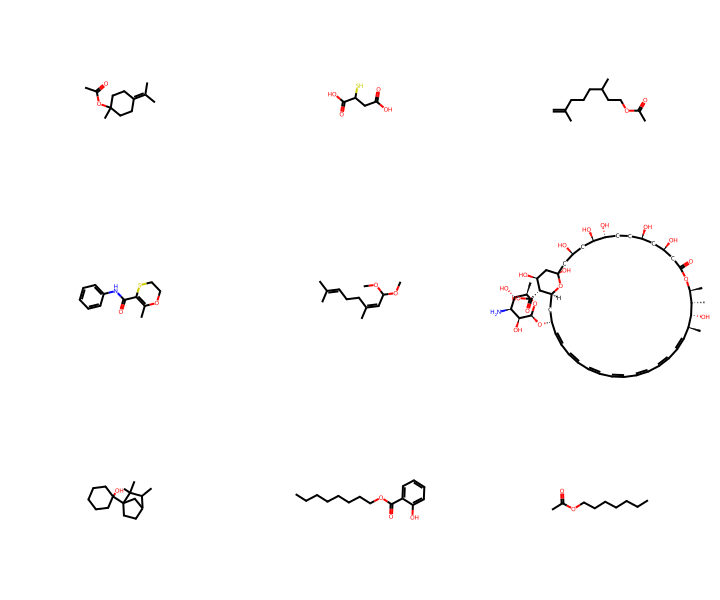

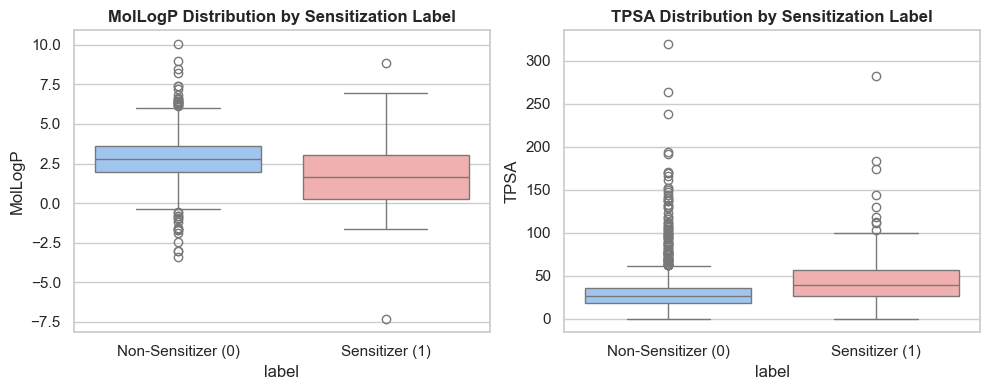

In [10]:
# Sample representative chemical structures from the skin sensitization cohort
np.random.seed(42)
sample_smiles = sensitization_final["standardized_smi"].sample(9, random_state=42)
mols = [Chem.MolFromSmiles(smi) for smi in sample_smiles if Chem.MolFromSmiles(smi) is not None]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(240, 200), returnPNG=False)
display(img)

# Compare MolLogP and TPSA distributions by toxicity label
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=sensitization_desc, x="label", y="MolLogP", palette=["#93c5fd", "#fca5a5"], ax=axes[0])
axes[0].set_title("MolLogP Distribution by Sensitization Label", fontweight="bold")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Non-Sensitizer (0)", "Sensitizer (1)"])

sns.boxplot(data=sensitization_desc, x="label", y="TPSA", palette=["#93c5fd", "#fca5a5"], ax=axes[1])
axes[1].set_title("TPSA Distribution by Sensitization Label", fontweight="bold")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-Sensitizer (0)", "Sensitizer (1)"])

plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "06_property_boxplots_by_label.png", dpi=300)
plt.show()


## 11. Local Processed Datasets Export

We save the standardized, curated datasets to `data/processed/` as standard UTF-8 `.csv` files for downstream modeling and cross-endpoint screening.


In [11]:
# Save curated chemical structures and labels
sensitization_final.to_csv(DATA_PROCESSED_DIR / "skin_sensitization_clean.csv", index=False)
irritation_final.to_csv(DATA_PROCESSED_DIR / "skin_irritation_clean.csv", index=False)
eye_final.to_csv(DATA_PROCESSED_DIR / "eye_irritation_clean.csv", index=False)

# Save 2D physicochemical descriptor tables
sensitization_desc.to_csv(DATA_PROCESSED_DIR / "skin_sensitization_descriptors.csv", index=False)
irritation_desc.to_csv(DATA_PROCESSED_DIR / "skin_irritation_descriptors.csv", index=False)
eye_desc.to_csv(DATA_PROCESSED_DIR / "eye_irritation_descriptors.csv", index=False)

# Save fingerprint tables
sensitization_fp.to_csv(DATA_PROCESSED_DIR / "skin_sensitization_fingerprints.csv", index=False)
irritation_fp.to_csv(DATA_PROCESSED_DIR / "skin_irritation_fingerprints.csv", index=False)
eye_fp.to_csv(DATA_PROCESSED_DIR / "eye_irritation_fingerprints.csv", index=False)

sensitization_maccs.to_csv(DATA_PROCESSED_DIR / "skin_sensitization_maccs.csv", index=False)
irritation_maccs.to_csv(DATA_PROCESSED_DIR / "skin_irritation_maccs.csv", index=False)
eye_maccs.to_csv(DATA_PROCESSED_DIR / "eye_irritation_maccs.csv", index=False)

# Save external combined descriptor dataset for virtual screening
external_combined = pd.concat([irritation_desc, eye_desc], ignore_index=True)
external_combined.to_csv(DATA_PROCESSED_DIR / "external_combined_descriptors.csv", index=False)

skin_irritation_structures = set(irritation_final["standardized_smi"])
eye_irritation_structures = set(eye_final["standardized_smi"])
auxiliary_overlap = skin_irritation_structures.intersection(eye_irritation_structures)
auxiliary_union = skin_irritation_structures.union(eye_irritation_structures)
auxiliary_summary = pd.DataFrame([
    {"cohort": "Skin Sensitization (training)", "endpoint_records": len(sensitization_final),
     "unique_standardized_structures": sensitization_final["standardized_smi"].nunique(),
     "class_1": int((sensitization_final["label"] == 1).sum()), "class_0": int((sensitization_final["label"] == 0).sum()),
     "cross_auxiliary_overlap": np.nan},
    {"cohort": "Skin Irritation (auxiliary)", "endpoint_records": len(irritation_final),
     "unique_standardized_structures": len(skin_irritation_structures),
     "class_1": int((irritation_final["label"] == 1).sum()), "class_0": int((irritation_final["label"] == 0).sum()),
     "cross_auxiliary_overlap": len(auxiliary_overlap)},
    {"cohort": "Eye Irritation classification endpoints (auxiliary)", "endpoint_records": len(eye_final),
     "unique_standardized_structures": len(eye_irritation_structures),
     "class_1": int((eye_final["label"] == 1).sum()), "class_0": int((eye_final["label"] == 0).sum()),
     "cross_auxiliary_overlap": len(auxiliary_overlap)},
    {"cohort": "Combined auxiliary endpoint records", "endpoint_records": len(external_combined),
     "unique_standardized_structures": len(auxiliary_union), "class_1": np.nan, "class_0": np.nan,
     "cross_auxiliary_overlap": len(auxiliary_overlap)},
])
auxiliary_summary.to_csv(RESULTS_TAB_DIR / "auxiliary_cohort_summary.csv", index=False)
print("Auxiliary records:", len(external_combined), "| unique structures:", len(auxiliary_union),
      "| structures shared across endpoint cohorts:", len(auxiliary_overlap))

print("Exported files in data/processed/:")
for p in sorted(DATA_PROCESSED_DIR.glob("*.csv")):
    df_temp = pd.read_csv(p)
    print(f"  {p.name:<38} : shape {str(df_temp.shape):<14}")


Auxiliary records: 533 | unique structures: 388 | structures shared across endpoint cohorts: 145
Exported files in data/processed/:
  external_combined_descriptors.csv      : shape (533, 19)     
  eye_irritation_clean.csv               : shape (333, 8)      
  eye_irritation_descriptors.csv         : shape (333, 19)     
  eye_irritation_fingerprints.csv        : shape (333, 1025)   
  eye_irritation_maccs.csv               : shape (333, 168)    


  skin_irritation_clean.csv              : shape (200, 8)      
  skin_irritation_descriptors.csv        : shape (200, 19)     
  skin_irritation_fingerprints.csv       : shape (200, 1025)   
  skin_irritation_maccs.csv              : shape (200, 168)    
  skin_sensitization_clean.csv           : shape (1185, 8)     
  skin_sensitization_descriptors.csv     : shape (1185, 19)    


  skin_sensitization_fingerprints.csv    : shape (1185, 1025)  
  skin_sensitization_maccs.csv           : shape (1185, 168)   
